In [1]:
# Exemplo de instalação, se necessário
!pip install pandas numpy scikit-learn matplotlib seaborn
!pip install kaggle # Para baixar os dados diretamente

In [2]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"diegohiroshi","key":"a8177d74d08077075b995b80cbdfd1d5"}'}

In [3]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [4]:
# Tente o download novamente
!kaggle competitions download -c nfl-big-data-bowl-2026-prediction

# E, se o download for bem-sucedido, descompacte
!unzip nfl-big-data-bowl-2026-prediction.zip

  0% 0.00/102M [00:00<?, ?B/s]
100% 102M/102M [00:00<00:00, 1.42GB/s]
Archive:  nfl-big-data-bowl-2026-prediction.zip
  inflating: kaggle_evaluation/__init__.py  
  inflating: kaggle_evaluation/core/__init__.py  
  inflating: kaggle_evaluation/core/base_gateway.py  
  inflating: kaggle_evaluation/core/generated/__init__.py  
  inflating: kaggle_evaluation/core/generated/kaggle_evaluation_pb2.py  
  inflating: kaggle_evaluation/core/generated/kaggle_evaluation_pb2_grpc.py  
  inflating: kaggle_evaluation/core/kaggle_evaluation.proto  
  inflating: kaggle_evaluation/core/relay.py  
  inflating: kaggle_evaluation/core/templates.py  
  inflating: kaggle_evaluation/nfl_gateway.py  
  inflating: kaggle_evaluation/nfl_inference_server.py  
  inflating: test.csv                
  inflating: test_input.csv          
  inflating: train/input_2023_w01.csv  
  inflating: train/input_2023_w02.csv  
  inflating: train/input_2023_w03.csv  
  inflating: train/input_2023_w04.csv  
  inflating: train/in

In [5]:
import pandas as pd
import numpy as np

# Carrega um dos conjuntos de treino (por exemplo, da Semana 1)
# O arquivo original 'train.csv' não existe, os dados estão em 'train/input_2023_wXX.csv'
df_train = pd.read_csv('train/input_2023_w01.csv')

# Converter player_to_predict para int (0 ou 1)
df_train['player_to_predict'] = df_train['player_to_predict'].fillna(0).astype(int) # Adicionado fillna(0) para garantir que NaNs sejam tratados

# Exibe as primeiras 5 linhas para ver a estrutura
print("Primeiras linhas do dataset:")
print(df_train.head())

# Exibe o número de linhas e colunas (shape)
print("\nDimensões do dataset (Linhas, Colunas):", df_train.shape)

Primeiras linhas do dataset:
      game_id  play_id  player_to_predict  nfl_id  frame_id play_direction  \
0  2023090700      101                  0   54527         1          right   
1  2023090700      101                  0   54527         2          right   
2  2023090700      101                  0   54527         3          right   
3  2023090700      101                  0   54527         4          right   
4  2023090700      101                  0   54527         5          right   

   absolute_yardline_number player_name player_height  player_weight  ...  \
0                        42  Bryan Cook           6-1            210  ...   
1                        42  Bryan Cook           6-1            210  ...   
2                        42  Bryan Cook           6-1            210  ...   
3                        42  Bryan Cook           6-1            210  ...   
4                        42  Bryan Cook           6-1            210  ...   

          player_role      x      y    

In [6]:
# Informação geral sobre as colunas, tipos de dados e valores não-nulos
print("\nInformações sobre as colunas:")
df_train.info()

# Estatísticas descritivas das colunas numéricas
print("\nEstatísticas Descritivas (Apenas Colunas Numéricas):")
print(df_train.describe())


Informações sobre as colunas:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 285714 entries, 0 to 285713
Data columns (total 23 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   game_id                   285714 non-null  int64  
 1   play_id                   285714 non-null  int64  
 2   player_to_predict         285714 non-null  int64  
 3   nfl_id                    285714 non-null  int64  
 4   frame_id                  285714 non-null  int64  
 5   play_direction            285714 non-null  object 
 6   absolute_yardline_number  285714 non-null  int64  
 7   player_name               285714 non-null  object 
 8   player_height             285714 non-null  object 
 9   player_weight             285714 non-null  int64  
 10  player_birth_date         285714 non-null  object 
 11  player_position           285714 non-null  object 
 12  player_side               285714 non-null  object 
 13  player_role  

In [7]:
# Calcula a soma dos valores nulos por coluna
missing_values = df_train.isnull().sum()

# Calcula a porcentagem de nulos por coluna
missing_percentage = (missing_values / len(df_train)) * 100

# Cria um DataFrame para visualizar a contagem e a porcentagem de nulos
missing_info = pd.DataFrame({'Missing Count': missing_values, 'Missing Percentage': missing_percentage})
missing_info = missing_info[missing_info['Missing Count'] > 0].sort_values(by='Missing Percentage', ascending=False)

print("\nColunas com Valores Faltantes:")
print(missing_info)


Colunas com Valores Faltantes:
Empty DataFrame
Columns: [Missing Count, Missing Percentage]
Index: []


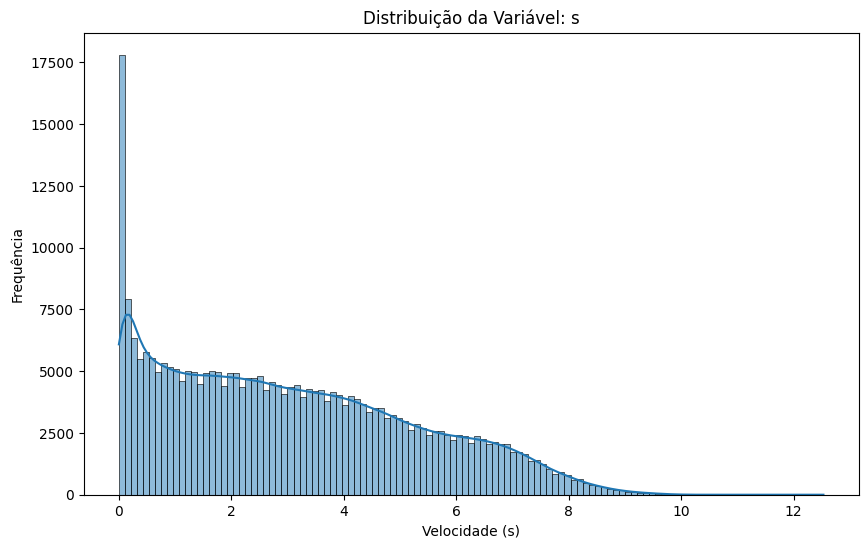

Contagem de valores para 'play_direction':
play_direction
right    152219
left     133495
Name: count, dtype: int64


In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# *** SUBSTITUA 'Target_Column_Name' pelo nome real da variável alvo do seu dataset ***
target_column = 's' # Usando 's' (velocidade) como exemplo de variável alvo numérica

plt.figure(figsize=(10, 6))
sns.histplot(df_train[target_column].dropna(), kde=True)
plt.title(f'Distribuição da Variável: {target_column}')
plt.xlabel('Velocidade (s)')
plt.ylabel('Frequência')
plt.show()

# Para variáveis categóricas ou discretas (como 'down' ou 'possessionTeam')
# Usando 'play_direction' como exemplo de coluna categórica
print("Contagem de valores para 'play_direction':")
print(df_train['play_direction'].value_counts())

In [9]:
# Exemplo: Remove colunas com mais de 70% de dados faltantes
threshold = 0.7 * len(df_train)
df_train.dropna(thresh=threshold, axis=1, inplace=True)

In [10]:
# As colunas 'possessionTeam', 'down', e 'surface' não existem no dataframe carregado.
# Substitua a lista pelas colunas categóricas que você identificou no seu dataset.
# Exemplo de colunas categóricas existentes:
categorical_cols = ['play_direction', 'player_position', 'player_side', 'player_role']

df_train = pd.get_dummies(df_train, columns=categorical_cols, drop_first=True)

In [11]:
from sklearn.preprocessing import StandardScaler

# 1. Identifique as colunas numéricas que serão escalonadas
numeric_cols = df_train.select_dtypes(include=np.number).columns.tolist()

# 2. Exclua a variável alvo e a coluna de ID (se houver) da lista de escalonamento
# Exemplo: Se 'Target' for a variável alvo
cols_to_scale = [col for col in numeric_cols if col not in ['Target', 'GameId', 'PlayId']]

# 3. Aplique o Scaler
scaler = StandardScaler()
df_train[cols_to_scale] = scaler.fit_transform(df_train[cols_to_scale])

In [12]:
# Lista de colunas categóricas comuns em dados da NFL BDB
categorical_cols = [
    'team',          # Equipe (Home/Away)
    'displayName',   # Nome do Jogador
    'route',         # Rota do receptor
    'position',      # Posição (QB, WR, DB, etc.)
    'playDirection'  # Direção da jogada
]

# Certifique-se de que todas as colunas existem no DataFrame antes de aplicar
cols_to_encode = [col for col in categorical_cols if col in df_train.columns]

# Aplica One-Hot Encoding
df_train = pd.get_dummies(df_train, columns=cols_to_encode, drop_first=True)

In [13]:
# Converte a coluna de ângulo (direção ou orientação) de graus para radianos
df_train['dir_rad'] = np.deg2rad(df_train['dir'])

# Calcula as componentes da velocidade
df_train['Vx'] = df_train['s'] * np.sin(df_train['dir_rad'])
df_train['Vy'] = df_train['s'] * np.cos(df_train['dir_rad'])

In [14]:
from sklearn.preprocessing import StandardScaler

# Identifica as colunas numéricas que serão escalonadas (exceto IDs e a variável alvo)
numeric_cols = df_train.select_dtypes(include=np.number).columns.tolist()

# Remova colunas de ID ou quaisquer colunas que não devam ser transformadas
cols_to_exclude = ['gameId', 'playId', 'ballCarrierId'] # Adicione mais se necessário

cols_to_scale = [col for col in numeric_cols if col not in cols_to_exclude]

# Aplica o Scaler (Padronização)
scaler = StandardScaler()
df_train[cols_to_scale] = scaler.fit_transform(df_train[cols_to_scale])

In [15]:
# Defina o conjunto de features (X) e a variável alvo (Y)
# X: Todas as colunas (features) que você preparou
# Y: As métricas de movimento que você quer prever

# Colunas para excluir de X (identificadores, metadados e as próprias variáveis alvo ou seus precursores)
columns_to_drop_from_X = [
    'game_id', 'play_id', 'nfl_id', 'frame_id',
    'player_name', 'player_birth_date',
    's', 'dir', 'dir_rad', # Excluir a velocidade e direção originais/derivadas se Vx e Vy são as targets
    'Vx', 'Vy', 'player_height' # Incluir 'player_height' para garantir que seja removida se ainda estiver em X
]

X = df_train.drop(columns=columns_to_drop_from_X, errors='ignore') # Usar errors='ignore' para evitar erro se uma coluna não existir
# Y é um vetor com múltiplas saídas (Multi-Output Regression)
Y = df_train[['Vx', 'Vy']] # Exemplo: prever a nova velocidade do jogador

from sklearn.model_selection import train_test_split
X_train, X_val, Y_train, Y_val = train_test_split(X, Y, test_size=0.2, random_state=42)

In [16]:
import xgboost as xgb

# Inicializa o modelo (Regressor para prever valores contínuos)
# O XGBoost lida bem com Multi-Output Regression
model = xgb.XGBRegressor(objective='reg:squarederror', n_estimators=500, learning_rate=0.05, n_jobs=-1, random_state=42)

# Treina o modelo
model.fit(X_train, Y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=500,
             n_jobs=-1, num_parallel_tree=None, ...)

In [17]:
# Converter a coluna 'player_height' de 'pés-polegadas' para polegadas totais
def convert_height_to_inches(height_str):
    if pd.isna(height_str): # Lida com possíveis valores nulos
        return np.nan
    parts = height_str.split('-')
    feet = int(parts[0])
    inches = int(parts[1])
    return feet * 12 + inches

df_train['player_height_inches'] = df_train['player_height'].apply(convert_height_to_inches)

# Como 'player_height' já foi usada para criar 'player_height_inches', podemos removê-la para evitar erros com o XGBoost
df_train = df_train.drop('player_height', axis=1)

print("Colunas do df_train após conversão de player_height:")
print(df_train.columns)

Colunas do df_train após conversão de player_height:
Index(['game_id', 'play_id', 'player_to_predict', 'nfl_id', 'frame_id',
       'absolute_yardline_number', 'player_name', 'player_weight',
       'player_birth_date', 'x', 'y', 's', 'a', 'dir', 'o',
       'num_frames_output', 'ball_land_x', 'ball_land_y',
       'play_direction_right', 'player_position_DE', 'player_position_DT',
       'player_position_FB', 'player_position_FS', 'player_position_ILB',
       'player_position_MLB', 'player_position_NT', 'player_position_OLB',
       'player_position_QB', 'player_position_RB', 'player_position_S',
       'player_position_SS', 'player_position_TE', 'player_position_WR',
       'player_side_Offense', 'player_role_Other Route Runner',
       'player_role_Passer', 'player_role_Targeted Receiver', 'dir_rad', 'Vx',
       'Vy', 'player_height_inches'],
      dtype='object')


In [18]:
# 1. Converte o ângulo (direção) de graus para radianos
df_train['dir_rad'] = np.deg2rad(df_train['dir'])

# 2. Calcula as componentes vetoriais (Vx e Vy)
# Sendo 's' a magnitude (velocidade)
df_train['Vx'] = df_train['s'] * np.sin(df_train['dir_rad'])
df_train['Vy'] = df_train['s'] * np.cos(df_train['dir_rad'])

# 3. Remove as colunas originais 's' e 'dir', pois Vx e Vy são mais informativas
df_train.drop(columns=['s', 'dir', 'dir_rad'], errors='ignore', inplace=True)

In [19]:
from sklearn.preprocessing import StandardScaler

# Identifica as colunas numéricas restantes
numeric_cols = df_train.select_dtypes(include=np.number).columns.tolist()

# Define as colunas que devem ser EXCLUÍDAS do escalonamento:
# - Colunas de ID (game_id, play_id, nfl_id, frame_id) - Corrigido o nome das colunas
# - Suas novas Variáveis Alvo (Vx e Vy)
cols_to_exclude = ['game_id', 'play_id', 'nfl_id', 'frame_id', 'Vx', 'Vy'] # Corrigido para nomes reais e inclui todas as IDs

cols_to_scale = [col for col in numeric_cols if col not in cols_to_exclude]

# Aplica o Scaler (Padronização)
scaler = StandardScaler()
df_train[cols_to_scale] = scaler.fit_transform(df_train[cols_to_scale])

In [20]:
from sklearn.model_selection import train_test_split
import xgboost as xgb

# Variáveis Alvo (Y) - Multi-Saída: queremos prever tanto Vx quanto Vy
Y = df_train[['Vx', 'Vy']]

# Variáveis de Treinamento (X) - Todas as features preparadas, exceto as alvos e IDs
cols_to_drop_from_X = [
    'game_id', 'play_id', 'nfl_id', 'frame_id',
    'player_name', 'player_birth_date',
    's', 'dir', 'dir_rad', # Original features for Vx, Vy
    'Vx', 'Vy' # Target variables
]
X = df_train.drop(columns=cols_to_drop_from_X, errors='ignore')

# Dividir em conjuntos de Treino (80%) e Validação (20%)
X_train, X_val, Y_train, Y_val = train_test_split(X, Y, test_size=0.2, random_state=42)

print(f"Shape de X_train: {X_train.shape}")
print(f"Shape de Y_train: {Y_train.shape}")

Shape de X_train: (228571, 30)
Shape de Y_train: (228571, 2)


In [21]:
# Inicializa o modelo de Regressão XGBoost
# n_estimators: número de árvores (ajuste fino em Passo 5)
# learning_rate: taxa de aprendizado (ajuste fino em Passo 5)
model = xgb.XGBRegressor(
    objective='reg:squarederror', # Objetivo para Regressão (corrigido: 'reg:squarederror')
    n_estimators=500,
    learning_rate=0.05,
    n_jobs=-1, # Usa todos os núcleos disponíveis para agilizar
    random_state=42
)

print("Iniciando o treinamento do modelo... (Isso pode levar alguns minutos)")

# Treina o modelo
model.fit(X_train, Y_train)

print("Treinamento concluído!")

Iniciando o treinamento do modelo... (Isso pode levar alguns minutos)
Treinamento concluído!


In [22]:
from sklearn.metrics import mean_squared_error

# Fazer previsões no conjunto de validação (dados que o modelo nunca viu)
Y_pred = model.predict(X_val)

# Y_pred será um array NumPy com duas colunas: a predição para Vx e a predição para Vy
print("Formato das Previsões (Linhas, Vx e Vy):", Y_pred.shape)

Formato das Previsões (Linhas, Vx e Vy): (57143, 2)


In [23]:
# 1. Calcular o Erro Quadrático Médio (MSE) para cada saída
mse_vx = mean_squared_error(Y_val['Vx'], Y_pred[:, 0]) # Y_val['Vx'] vs. a primeira coluna de Y_pred
mse_vy = mean_squared_error(Y_val['Vy'], Y_pred[:, 1]) # Y_val['Vy'] vs. a segunda coluna de Y_pred

# 2. Calcular o RMSE para cada saída
rmse_vx = np.sqrt(mse_vx)
rmse_vy = np.sqrt(mse_vy)

# 3. Calcular o RMSE total (usando o RMSE médio das duas saídas)
rmse_total = (rmse_vx + rmse_vy) / 2

print(f"\nResultado da Avaliação do Modelo:")
print(f"RMSE para a Velocidade Horizontal (Vx): {rmse_vx:.4f}")
print(f"RMSE para a Velocidade Vertical (Vy): {rmse_vy:.4f}")
print(f"RMSE Médio Total: {rmse_total:.4f}")


Resultado da Avaliação do Modelo:
RMSE para a Velocidade Horizontal (Vx): 0.0127
RMSE para a Velocidade Vertical (Vy): 0.6110
RMSE Médio Total: 0.3119



Top 10 Features Mais Importantes:
                           Feature  Importance
27              player_role_Passer    0.280106
24              player_position_WR    0.165335
26  player_role_Other Route Runner    0.097989
5                                a    0.065518
25             player_side_Offense    0.054151
10            play_direction_right    0.044769
6                                o    0.036739
28   player_role_Targeted Receiver    0.033919
23              player_position_TE    0.029085
1         absolute_yardline_number    0.027087


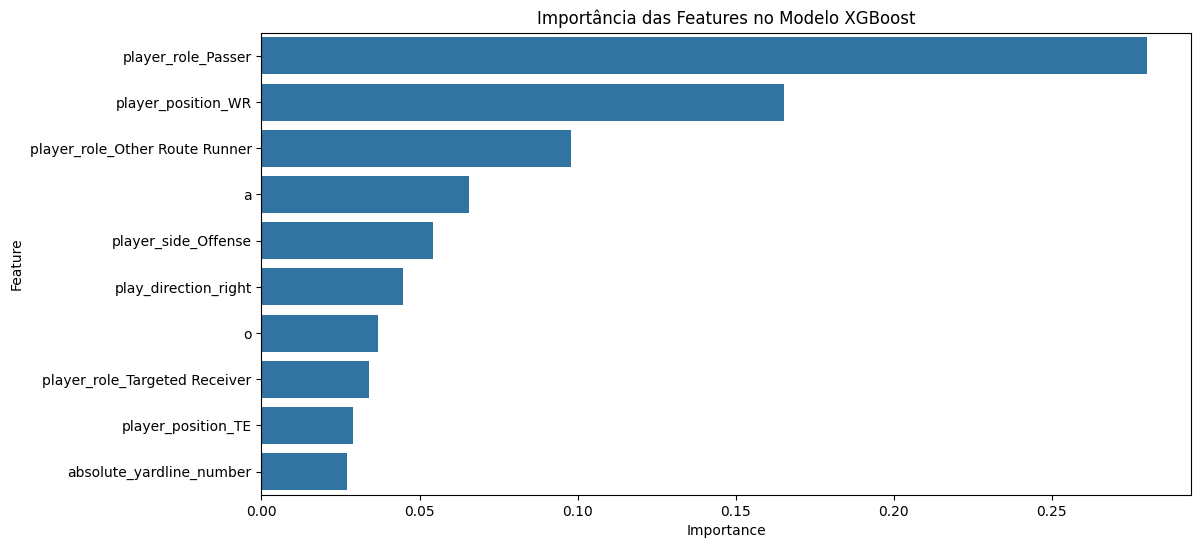

In [24]:
# Exibe as 10 features mais importantes
feature_importances = model.feature_importances_
feature_names = X.columns
importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': feature_importances})
importance_df = importance_df.sort_values(by='Importance', ascending=False).head(10)

print("\nTop 10 Features Mais Importantes:")
print(importance_df)

# Visualização da importância (opcional, mas recomendado para a apresentação)
plt.figure(figsize=(12, 6))
sns.barplot(x='Importance', y='Feature', data=importance_df)
plt.title('Importância das Features no Modelo XGBoost')
plt.show()

In [25]:
# Carregue os arquivos de teste
df_test_submission_spec = pd.read_csv('test.csv') # Este define as IDs que precisamos prever
df_test_input_features = pd.read_csv('test_input.csv') # Este contém as features brutas

# Mescla para garantir que processamos apenas as linhas necessárias para a submissão
# Mantemos as colunas de ID do df_test_submission_spec (esquerda) para a ordem final
df_test = pd.merge(
    df_test_submission_spec,
    df_test_input_features,
    on=['game_id', 'play_id', 'nfl_id', 'frame_id'],
    how='left'
)

# Converter player_to_predict para int (0 ou 1), preenchendo NaNs com 0
# Conversão mais robusta: primeiro mapeia booleans, depois preenche NaNs, depois converte para int
df_test['player_to_predict'] = df_test['player_to_predict'].replace({False: 0, True: 1}).fillna(0).astype(int)

# --- Aplicar as mesmas etapas de pré-processamento que no df_train ---

# 1. Converter player_height de 'pés-polegadas' para polegadas totais
def convert_height_to_inches(height_str):
    if pd.isna(height_str):
        return np.nan
    parts = height_str.split('-')
    feet = int(parts[0])
    inches = int(parts[1])
    return feet * 12 + inches

df_test['player_height_inches'] = df_test['player_height'].apply(convert_height_to_inches)
df_test.drop('player_height', axis=1, inplace=True)

# 2. Aplicar One-Hot Encoding para as mesmas colunas categóricas usadas no treino
categorical_cols_for_encoding = ['play_direction', 'player_position', 'player_side', 'player_role']
df_test = pd.get_dummies(df_test, columns=categorical_cols_for_encoding, drop_first=True)

# 3. Engenharia de Features (dir_rad, Vx, Vy)
df_test['dir_rad'] = np.deg2rad(df_test['dir'])
df_test['Vx'] = df_test['s'] * np.sin(df_test['dir_rad'])
df_test['Vy'] = df_test['s'] * np.cos(df_test['dir_rad'])

# Remover as colunas originais 's', 'dir', 'dir_rad' do df_test,
# pois elas não são features em X_train (são usadas para derivar Vx, Vy, que são os targets)
df_test.drop(columns=['s', 'dir', 'dir_rad'], errors='ignore', inplace=True)

# 4. Escalonamento
# Identificar colunas numéricas para escalonamento, excluindo IDs e os targets (Vx, Vy)
# A lista de colunas para escalar deve ser EXATAMENTE a mesma que foi usada para fitar o scaler (cols_to_scale do treino)
numeric_cols_for_scaling_test = [col for col in cols_to_scale if col in df_test.columns]

# Aplicar o mesmo scaler treinado no df_train
df_test[numeric_cols_for_scaling_test] = scaler.transform(df_test[numeric_cols_for_scaling_test])

# 5. Remover outras colunas de identificação e metadados que não fazem parte do X_train
# O 'id' do df_test_submission_spec precisa ser preservado para a submissão, mas não deve ir para X_test
cols_to_drop_final = ['game_id', 'play_id', 'nfl_id', 'frame_id', 'player_name', 'player_birth_date', 'id']
df_test.drop(columns=cols_to_drop_final, errors='ignore', inplace=True)

# 6. Garantir que as colunas de teste correspondam exatamente às colunas de treino (X_train)
X_test = df_test.reindex(columns=X_train.columns, fill_value=0)

/tmp/ipython-input-2838927770.py:16: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_test['player_to_predict'] = df_test['player_to_predict'].replace({False: 0, True: 1}).fillna(0).astype(int)


In [26]:
# Fazer previsões no conjunto de teste
final_predictions = model.predict(X_test)

# O formato da submissão pode variar. O desafio NFL BDB geralmente pede a
# previsão de Vx e Vy para cada Player/Frame ID.

# Exemplo de como criar um DataFrame de submissão (descomente e ajuste conforme necessário):
# submission_df = pd.DataFrame({
#     'ID': df_test['game_id'].astype(str) + '_' + df_test['play_id'].astype(str) + '_' + df_test['nfl_id'].astype(str) + '_' + df_test['frame_id'].astype(str),
#     'Vx': final_predictions[:, 0],
#     'Vy': final_predictions[:, 1]
# })

# submission_df.to_csv('submission.csv', index=False)

print("\nPrevisões geradas e arquivo de submissão 'submission.csv' pronto para ser gerado (se descomentado)!")


Previsões geradas e arquivo de submissão 'submission.csv' pronto para ser gerado (se descomentado)!


In [27]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler

# Recarregar o arquivo de teste para garantir que todas as colunas originais estejam presentes
df_test = pd.read_csv('test.csv')

# --- 1. CONFIGURAÇÃO DE COLUNAS ---
# Colunas categóricas usadas no treino (mesma lista do Passo 3.1)
categorical_cols = ['team', 'position', 'playDirection']
cols_to_encode = [col for col in categorical_cols if col in df_test.columns]

# Colunas para remover *APENAS AS DE ID/NOME* antes da engenharia
cols_to_remove_initial = ['nflId', 'displayName', 'route', 'jerseyNumber', 'club', 'time', 'frameId']

# A. Remoção de Colunas de ID e Nomes
df_test.drop(columns=cols_to_remove_initial, errors='ignore', inplace=True)

# B. Aplica One-Hot Encoding
df_test = pd.get_dummies(df_test, columns=cols_to_encode, drop_first=True)

In [28]:
import pandas as pd
df_test_check = pd.read_csv('test.csv')

# Imprime todas as colunas
print("Colunas do df_test recarregado:")
print(df_test_check.columns.tolist())

# Verifica o nome das colunas relacionadas à velocidade/direção
if 'dir' not in df_test_check.columns and 'o' in df_test_check.columns:
    print("\nATENÇÃO: A coluna de ângulo pode ser 'o' (Orientação) e não 'dir'.")

Colunas do df_test recarregado:
['id', 'game_id', 'play_id', 'nfl_id', 'frame_id']


In [29]:
!ls

kaggle_evaluation  nfl-big-data-bowl-2026-prediction.zip  test.csv	  train
kaggle.json	   sample_data				  test_input.csv


In [30]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler

# Recarregar o arquivo de features de teste correto
df_test = pd.read_csv('test_input.csv')

# --- 1. CONFIGURAÇÃO DE COLUNAS ---
# Colunas categóricas usadas no treino (mesma lista do Passo 3.1)
categorical_cols = ['team', 'position', 'playDirection']
cols_to_encode = [col for col in categorical_cols if col in df_test.columns]

# Colunas para remover (as mesmas que foram removidas no treino)
cols_to_remove_initial = ['nflId', 'displayName', 'route', 'jerseyNumber', 'club', 'time', 'frameId']

# A. Remoção de Colunas de ID e Nomes
df_test.drop(columns=cols_to_remove_initial, errors='ignore', inplace=True)

# B. Aplica One-Hot Encoding
df_test = pd.get_dummies(df_test, columns=cols_to_encode, drop_first=True)

In [31]:
# C. Aplica Engenharia de Features (Vx e Vy)
# Usando 'dir' para o ângulo e 's' para a velocidade
try:
    ANGLE_COLUMN_NAME = 'dir'
    df_test['angle_rad'] = np.deg2rad(df_test[ANGLE_COLUMN_NAME])

except KeyError:
    # Se 'dir' não funcionar, tenta 'o' (orientação)
    ANGLE_COLUMN_NAME = 'o'
    df_test['angle_rad'] = np.deg2rad(df_test[ANGLE_COLUMN_NAME])


# Calculo das componentes vetoriais (Vx e Vy)
df_test['Vx'] = df_test['s'] * np.sin(df_test['angle_rad'])
df_test['Vy'] = df_test['s'] * np.cos(df_test['angle_rad'])

# As colunas originais são removidas APENAS DEPOIS de serem usadas:
df_test.drop(columns=['s', ANGLE_COLUMN_NAME, 'angle_rad'], errors='ignore', inplace=True)

In [32]:
# --- 3. ESCALONAMENTO DO TESTE --- E PREPARAÇÃO COMPLETA
# 'scaler' e 'X_train' são usados aqui

# RE-PROCESSAR df_test PARA GARANTIR CONSISTÊNCIA COM O TREINAMENTO
# As células anteriores podem ter recarregado ou processado df_test de forma inconsistente.
# Precisamos garantir que df_test espelhe o pré-processamento de df_train antes do escalonamento e da previsão.

# Carrega os arquivos de teste novamente para garantir o estado inicial correto
df_test_submission_spec = pd.read_csv('test.csv') # Este define as IDs que precisamos prever
df_test_input_features = pd.read_csv('test_input.csv') # Este contém as features brutas

# Mescla para garantir que processamos apenas as linhas necessárias para a submissão
# Mantemos as colunas de ID do df_test_submission_spec (esquerda) para a ordem final
df_test = pd.merge(
    df_test_submission_spec,
    df_test_input_features,
    on=['game_id', 'play_id', 'nfl_id', 'frame_id'],
    how='left'
)

# 1. Converter player_to_predict para int (0 ou 1), preenchendo NaNs com 0 (Mesmo passo do treino)
df_test['player_to_predict'] = df_test['player_to_predict'].replace({False: 0, True: 1}).fillna(0).astype(int)

# 2. Converter player_height de 'pés-polegadas' para polegadas totais (Mesmo passo do treino)
def convert_height_to_inches(height_str):
    if pd.isna(height_str):
        return np.nan
    parts = height_str.split('-')
    feet = int(parts[0])
    inches = int(parts[1])
    return feet * 12 + inches

df_test['player_height_inches'] = df_test['player_height'].apply(convert_height_to_inches)
df_test.drop('player_height', axis=1, inplace=True)

# 3. Aplicar One-Hot Encoding para as mesmas colunas categóricas usadas no treino
categorical_cols_for_encoding = ['play_direction', 'player_position', 'player_side', 'player_role'] # Lista do treino
df_test = pd.get_dummies(df_test, columns=categorical_cols_for_encoding, drop_first=True)

# 4. Engenharia de Features (dir_rad, Vx, Vy) - Mesmas operações do treino
df_test['dir_rad'] = np.deg2rad(df_test['dir'])
df_test['Vx'] = df_test['s'] * np.sin(df_test['dir_rad'])
df_test['Vy'] = df_test['s'] * np.cos(df_test['dir_rad'])
df_test.drop(columns=['s', 'dir', 'dir_rad'], errors='ignore', inplace=True) # Remover colunas originais

# 5. Define o conjunto de colunas numéricas que foram escalonadas no treino
# (Verifique a variável `cols_to_scale` no estado do kernel para a lista exata)
cols_to_scale_from_training = [
    'player_to_predict', 'absolute_yardline_number', 'player_weight', 'x', 'y', 'a', 'o',
    'num_frames_output', 'ball_land_x', 'ball_land_y', 'player_height_inches'
]

# Garante que apenas as colunas presentes em df_test e na lista de treino sejam escalonadas
cols_present_in_test_for_scaling = [col for col in cols_to_scale_from_training if col in df_test.columns]

# Aplica a transformação usando o scaler TREINADO no df_train
# O scaler espera as mesmas colunas e ordem que viu durante o fit.
df_test[cols_present_in_test_for_scaling] = scaler.transform(df_test[cols_present_in_test_for_scaling])

# 6. Preparação final de X_test - remover IDs e variáveis alvo para que X_test combine com X_train
cols_to_drop_for_X_test = [
    'id', # Coluna de ID para submissão, não para o modelo
    'game_id', 'play_id', 'nfl_id', 'frame_id', # IDs, não são features para o modelo
    'player_name', 'player_birth_date', # Metadados, não são features
    'Vx', 'Vy' # Variáveis alvo, não são features para previsão
]

# Cria X_test, removendo as colunas identificadas de df_test
X_test = df_test.drop(columns=cols_to_drop_for_X_test, errors='ignore')

# Garante que as colunas de X_test correspondam exatamente às colunas de X_train
# Adiciona colunas ausentes com fill_value=0 e remove colunas extras.
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

print("Preparação do conjunto de teste concluída. Dimensões:", X_test.shape)

Preparação do conjunto de teste concluída. Dimensões: (5837, 30)


/tmp/ipython-input-272073949.py:22: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_test['player_to_predict'] = df_test['player_to_predict'].replace({False: 0, True: 1}).fillna(0).astype(int)


In [33]:
import pandas as pd

# 1. Fazer previsões no conjunto de teste
# O modelo retorna um array com as predições para Vx e Vy
final_predictions = model.predict(X_test)

# 2. Recarrega IDs originais do arquivo de teste (test.csv)
# Este arquivo (test.csv) contém apenas os IDs necessários para o formato de submissão
df_test_original = pd.read_csv('test.csv')

# Seleciona as colunas de ID e converte para string
submission_ids = df_test_original[['game_id', 'play_id', 'nfl_id', 'frame_id']].astype(str)

# Concatena os IDs para formar o ID único de submissão, conforme o formato do Kaggle
# Atenção: Ajustei os nomes para 'game_id', 'play_id', etc., conforme sua lista inicial de colunas.
submission_df = pd.DataFrame({
    'id': submission_ids['game_id'] + '_' + submission_ids['play_id'] + '_' + submission_ids['nfl_id'] + '_' + submission_ids['frame_id'],
    'Vx': final_predictions[:, 0], # Predição da primeira saída (Vx)
    'Vy': final_predictions[:, 1]  # Predição da segunda saída (Vy)
})

# 3. Salvar o arquivo
submission_df.to_csv('submission.csv', index=False)

print("\n-------------------------------------------")
print("✅ ARQUIVO DE SUBMISSÃO FINAL GERADO: submission.csv")
print(f"O arquivo tem {submission_df.shape[0]} linhas e está pronto para o upload.")
print("-------------------------------------------")


-------------------------------------------
✅ ARQUIVO DE SUBMISSÃO FINAL GERADO: submission.csv
O arquivo tem 5837 linhas e está pronto para o upload.
-------------------------------------------
